In [9]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import pandas as pd
from torchvision import models
import random
import matplotlib.pyplot as plt
import torch.optim as optim

# 디렉터리 및 모델 경로 설정
ROOT_DIR = "/home/bmegpu03/Metal_artifact/DATA/240_resize_for_train/dev"
SAVE_PATH = "/home/bmegpu03/Metal_artifact/other_models/ResNet50/MultiView/2"
AP_MODEL_PATH = '/home/bmegpu03/Metal_artifact/other_models/ResNet50/model/NowBest/AP.pth'
LAT_MODEL_PATH = '/home/bmegpu03/Metal_artifact/other_models/ResNet50/model/NowBest/LAT.pth'
MODEL_NAME = 'MultiView.pth'
os.makedirs(SAVE_PATH, exist_ok=True)

In [10]:
PATIENCE = 20
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-3

In [11]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = F.relu(out)

        return out

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = F.relu(out)

        return out

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

def ResNet50(num_classes=1):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes)

class MultiViewResNet50(nn.Module):
    def __init__(self, num_classes=1):
        super(MultiViewResNet50, self).__init__()

        # ResNet50 Backbone (AP View & LAT View)
        self.resnet1 = ResNet50()
        self.resnet1.fc = nn.Identity()  
        self.resnet2 = ResNet50()
        self.resnet2.fc = nn.Identity()  

        # Feature Fusion
        self.fusion_layer = nn.Linear(2048 * 2, 1024)
        self.relu = nn.ReLU()

        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x1, x2):
        feat1 = self.resnet1(x1)
        feat2 = self.resnet2(x2)

        # Feature Fusion
        fused_features = torch.cat((feat1, feat2), dim=1)
        fused_features = self.fusion_layer(fused_features)
        fused_features = self.relu(fused_features)

        output = self.classifier(fused_features)
        return output

In [12]:
# Early Stopping
class EarlyStopping:
    def __init__(self, patience=10, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [13]:
class MultiViewDataset(Dataset):
    def __init__(self, root_dir, train=True, split_ratio=0.1):
        self.root_dir = root_dir
        self.train = train
        self.data_dict = self._match_ap_lat()

        self.train_data, self.val_data = train_test_split(self.data_dict, test_size=split_ratio, random_state=42)
        
        self.transform_train = transforms.Compose([
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.RandomApply([transforms.GaussianBlur(3)], p=0.5),
            transforms.ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2)),
            transforms.Normalize(mean=[0.5], std=[0.5]),
        ])

        self.transform_val = transforms.Compose([
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def _match_ap_lat(self):
        ap_dict = {}
        lat_dict = {}

        for label_folder in os.listdir(self.root_dir):
            label_path = os.path.join(self.root_dir, label_folder)
            if os.path.isdir(label_path):
                ap_folder = os.path.join(label_path, "AP")
                lat_folder = os.path.join(label_path, "LAT")

                if os.path.isdir(ap_folder):
                    for img_file in os.listdir(ap_folder):
                        patient_id = img_file.split('_')[1]
                        study_date = img_file.split('_')[2].split('.')[0]
                        ap_dict[f"{patient_id}_{study_date}"] = (os.path.join(ap_folder, img_file), label_folder)

                if os.path.isdir(lat_folder):
                    for img_file in os.listdir(lat_folder):
                        patient_id = img_file.split('_')[1]
                        study_date = img_file.split('_')[2].split('.')[0]
                        lat_dict[f"{patient_id}_{study_date}"] = (os.path.join(lat_folder, img_file), label_folder)

        matched_data = []
        for key in ap_dict:
            if key in lat_dict:
                matched_data.append((ap_dict[key][0], lat_dict[key][0], int(ap_dict[key][1])))
        
        return matched_data

    def __len__(self):
        return len(self.train_data) if self.train else len(self.val_data)

    def __getitem__(self, idx):
        data = self.train_data if self.train else self.val_data
        ap_path, lat_path, label = data[idx]
        ap_image = Image.open(ap_path)
        lat_image = Image.open(lat_path)

        ap_image = np.array(ap_image, dtype=np.float32)
        lat_image = np.array(lat_image, dtype=np.float32)

        ap_image = (ap_image - np.min(ap_image)) / (np.max(ap_image) - np.min(ap_image) + 1e-7)
        lat_image = (lat_image - np.min(lat_image)) / (np.max(lat_image) - np.min(lat_image) + 1e-7)

        ap_image = torch.tensor(ap_image).unsqueeze(0)
        lat_image = torch.tensor(lat_image).unsqueeze(0)

        if self.train:
            ap_image = self.transform_train(ap_image)
            lat_image = self.transform_train(lat_image)
        else:
            ap_image = self.transform_val(ap_image)
            lat_image = self.transform_val(lat_image)

        img_name = os.path.basename(ap_path)
        parts = img_name.split('_')
        patient_id = parts[1]
        study_date = parts[2].split('.')[0]

        return ap_image, lat_image, patient_id, study_date, img_name, label

In [14]:
# ✅ **모델 로드 함수 (AP & LAT 개별 모델)**
def load_model(ap_model_path, lat_model_path):
    model = MultiViewResNet50().to(device)
    ap_state_dict = torch.load(ap_model_path, map_location=device)
    lat_state_dict = torch.load(lat_model_path, map_location=device)

    model.resnet1.load_state_dict(ap_state_dict, strict=False)
    model.resnet2.load_state_dict(lat_state_dict, strict=False)

    # 기존 모델의 가중치를 Freeze (Feature Extractor 방식 적용)
    for param in model.resnet1.parameters():
        param.requires_grad = False  # AP 모델의 가중치 고정

    for param in model.resnet2.parameters():
        param.requires_grad = False  # LAT 모델의 가중치 고정

    for param in model.resnet1.layer4.parameters():
        param.requires_grad = True
    for param in model.resnet2.layer4.parameters():
        param.requires_grad = True

    return model

In [15]:
train_dataset = MultiViewDataset(ROOT_DIR, train=True)
val_dataset = MultiViewDataset(ROOT_DIR, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [16]:
#define loss funtion & optimizer
model = load_model(AP_MODEL_PATH, LAT_MODEL_PATH)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_loss = float('inf')
best_val_acc = 0
early_stopping = EarlyStopping(patience=PATIENCE, delta=0.001)
train_loss_list, val_loss_list, train_acc_list, val_acc_list = [], [], [], []

/tmp/ipykernel_166793/3851606269.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ap_state_dict = torch.load(ap_model_path, map_location=device)
/tmp/ipykernel_166793/385

Epoch 1/50 - Loss: 0.4521 - Accuracy: 78.87%
Validation Loss: 0.6594 - Validation Accuracy: 80.28%
✅ Best model saved!
Epoch 2/50 - Loss: 0.3180 - Accuracy: 86.70%
Validation Loss: 0.2253 - Validation Accuracy: 97.18%
✅ Best model saved!
Epoch 3/50 - Loss: 0.3113 - Accuracy: 86.54%
Validation Loss: 0.2162 - Validation Accuracy: 88.73%
✅ Best model saved!
Epoch 4/50 - Loss: 0.2878 - Accuracy: 86.38%
Validation Loss: 0.2052 - Validation Accuracy: 87.32%
✅ Best model saved!
Epoch 5/50 - Loss: 0.3073 - Accuracy: 87.48%
Validation Loss: 0.3416 - Validation Accuracy: 84.51%
Epoch 6/50 - Loss: 0.2923 - Accuracy: 87.17%
Validation Loss: 0.2624 - Validation Accuracy: 87.32%
Epoch 7/50 - Loss: 0.3004 - Accuracy: 87.17%
Validation Loss: 0.3140 - Validation Accuracy: 92.96%
Epoch 8/50 - Loss: 0.3108 - Accuracy: 85.92%
Validation Loss: 0.2777 - Validation Accuracy: 85.92%
Epoch 9/50 - Loss: 0.2785 - Accuracy: 88.11%
Validation Loss: 0.1743 - Validation Accuracy: 92.96%
✅ Best model saved!
Epoch 10/

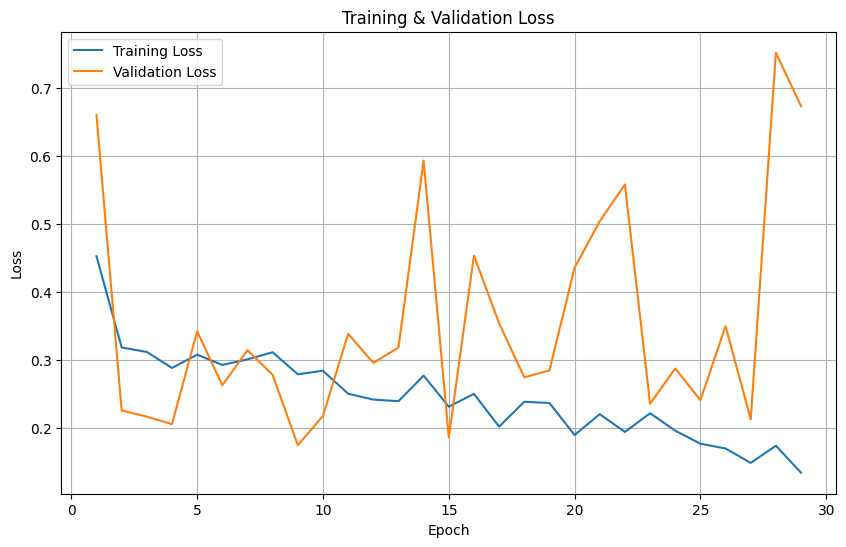

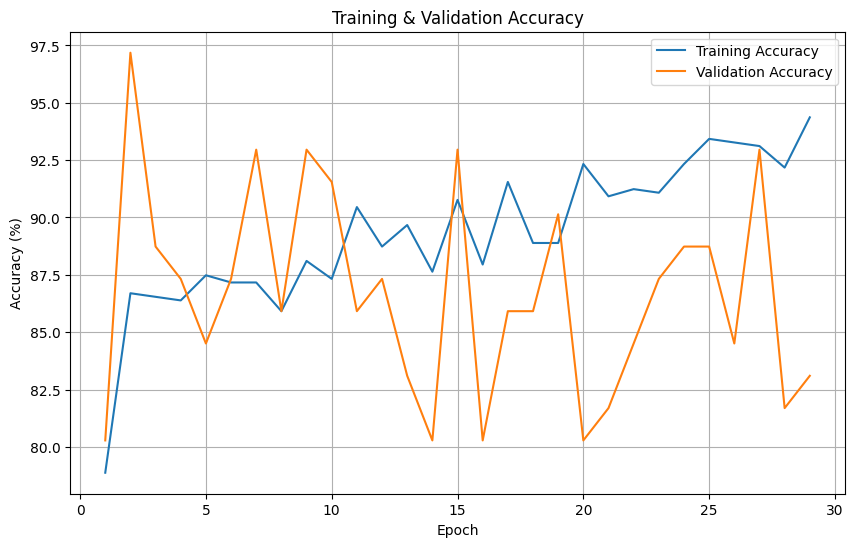

In [17]:
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch in train_loader:
        ap_images, lat_images, _, _, _, labels = batch  # Unpacking correctly
        ap_images, lat_images, labels = ap_images.to(device), lat_images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(ap_images, lat_images)
        
        labels = labels.float().unsqueeze(1)  # Ensure labels have correct shape for BCE Loss
        loss = criterion(outputs, labels)  # BCEWithLogitsLoss expects float labels
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).int().cpu().numpy()
        correct += (preds == labels.int()).sum().item()  # Ensure integer comparison
        total += labels.size(0)
        
        ap_images, lat_images, labels = ap_images.cpu(), lat_images.cpu(), labels.cpu()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total * 100
    train_loss_list.append(epoch_loss)
    train_acc_list.append(epoch_acc)
    print(f'Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%')

    # ✅ Validation Loop
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            ap_images, lat_images, _, _, _, labels = batch  # Unpacking correctly
            ap_images, lat_images, labels = ap_images.to(device), lat_images.to(device), labels.to(device)

            val_outputs = model(ap_images, lat_images)
            labels = labels.float().unsqueeze(1)  # Ensure labels are float and shaped correctly
            
            loss = criterion(val_outputs, labels)
            val_loss += loss.item()

            val_preds = (torch.sigmoid(val_outputs) > 0.5).int()
            val_correct += (val_preds == labels.int()).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total * 100
    val_loss_list.append(avg_val_loss)
    val_acc_list.append(val_acc)
    print(f'Validation Loss: {avg_val_loss:.4f} - Validation Accuracy: {val_acc:.2f}%')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), os.path.join(SAVE_PATH, 'MultiViewModel.pth'))
        print('✅ Best model saved!')

    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print("⏳ Early stopping triggered.")
        break

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_loss_list) + 1), train_loss_list, label='Training Loss')
plt.plot(range(1, len(val_loss_list) + 1), val_loss_list, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_acc_list) + 1), train_acc_list, label='Training Accuracy')
plt.plot(range(1, len(val_acc_list) + 1), val_acc_list, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()